In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

In [2]:
import neuroboros as nb
import numpy as np
from scipy.stats import ttest_rel
import scipy.stats as stats

In [ ]:
results = nb.load('Figure 4-Source Data.pkl')

In [4]:
list(results)

[('young', 'young', 'none'),
 ('young', 'young', 'procr'),
 ('old', 'young', 'none'),
 ('old', 'young', 'procr'),
 ('young', 'old', 'none'),
 ('young', 'old', 'procr'),
 ('old', 'old', 'none'),
 ('old', 'old', 'procr')]

In [5]:
for test_grp in ['old', 'young']:
    for tpl_grp in ['old', 'young']:
        for align in ['procr', 'none']:
            print(results[test_grp, tpl_grp, align].shape)

(10, 72, 19341)
(10, 72, 19341)
(10, 72, 19341)
(10, 72, 19341)
(10, 71, 19341)
(10, 71, 19341)
(10, 71, 19341)
(10, 71, 19341)


In [6]:
test_lists = nb.load('summary/camcan_test_lists.pkl')

In [7]:
zz = {}
for test_grp in ['old', 'young']:
    for tpl_grp in ['old', 'young']:
        for align in ['procr', 'none']:
            sid_results = {}
            for trial in range(10):
                sids = test_lists[test_grp, trial]
                vals = results[test_grp, tpl_grp, align][trial]
                for sid, val in zip(sids, vals):
                    if sid not in sid_results:
                        sid_results[sid] = []
                    sid_results[sid].append(val)
            res = [np.mean(np.arctanh(sid_results[sid]), axis=0) for sid in sid_results]
            print(np.unique([len(sid_results[sid]) for sid in sid_results], return_counts=True))
            res = np.stack(res, axis=0)
            print(res.shape)
            zz[test_grp, tpl_grp, align] = res.mean(axis=1)

(array([1, 2, 3, 4, 5, 6, 7, 8]), array([18, 43, 55, 51, 33, 10,  2,  1]))
(213, 19341)
(array([1, 2, 3, 4, 5, 6, 7, 8]), array([18, 43, 55, 51, 33, 10,  2,  1]))
(213, 19341)
(array([1, 2, 3, 4, 5, 6, 7, 8]), array([18, 43, 55, 51, 33, 10,  2,  1]))
(213, 19341)
(array([1, 2, 3, 4, 5, 6, 7, 8]), array([18, 43, 55, 51, 33, 10,  2,  1]))
(213, 19341)
(array([1, 2, 3, 4, 5, 6, 8]), array([19, 37, 62, 48, 27, 16,  1]))
(210, 19341)
(array([1, 2, 3, 4, 5, 6, 8]), array([19, 37, 62, 48, 27, 16,  1]))
(210, 19341)
(array([1, 2, 3, 4, 5, 6, 8]), array([19, 37, 62, 48, 27, 16,  1]))
(210, 19341)
(array([1, 2, 3, 4, 5, 6, 8]), array([19, 37, 62, 48, 27, 16,  1]))
(210, 19341)


In [8]:
for key in zz:
    print(key, zz[key].mean())

('old', 'old', 'procr') 0.20614858200385097
('old', 'old', 'none') 0.17581314952772914
('old', 'young', 'procr') 0.21046021282899632
('old', 'young', 'none') 0.17581314952772914
('young', 'old', 'procr') 0.329627697398875
('young', 'old', 'none') 0.28125557582797595
('young', 'young', 'procr') 0.3393307870801749
('young', 'young', 'none') 0.28125557582797595


In [9]:
rocket = sns.color_palette("rocket", 5)
mako = sns.color_palette("mako", 5)

colors = [mpl.colors.to_rgb(mpl.colors.cnames[_])
          for _ in ['darkgreen', 'lightgreen', 'red', 'pink']]

config = [
    [0, zz['old', 'old', 'procr'], rocket[2]],
    [1, zz['old', 'young', 'procr'], rocket[4]],
    [2.5, zz['young', 'young', 'procr'], mako[2]],
    [3.5, zz['young', 'old', 'procr'], mako[4]],
]

In [10]:
def bootstrap_mean(d, rng=0, n_reps=100000):
    n = d.shape[0]
    rng = np.random.default_rng(rng)
    stats = np.zeros((n_reps,))
    for i in range(n_reps):
        sample = rng.choice(d, (n,), replace=True)
        stats[i] = sample.mean()
    return stats

In [11]:
d1 = zz['old', 'old', 'procr'] - zz['old', 'young', 'procr']
d2 = zz['young', 'young', 'procr'] - zz['young', 'old', 'procr']

m1 = d1.mean()
se1 = d1.std(ddof=1) / np.sqrt(len(d1))
# b1 = bootstrap_mean(d1)
# yerr1 = np.abs(np.percentile(b1, [2.5, 97.5]) - m1)
m2 = d2.mean()
se2 = d2.std(ddof=1) / np.sqrt(len(d2))
# b2 = bootstrap_mean(d2)
# yerr2 = np.abs(np.percentile(b2, [2.5, 97.5]) - m2)


In [12]:
stats.ttest_1samp(d1, 0)

TtestResult(statistic=np.float64(-23.5878779497479), pvalue=np.float64(3.37017750710391e-61), df=np.int64(212))

In [13]:
stats.ttest_1samp(d2, 0)

TtestResult(statistic=np.float64(56.53425495748096), pvalue=np.float64(1.265872647276978e-128), df=np.int64(209))

(array([ 7., 10., 23., 26., 46., 44., 27., 17.,  8.,  5.]),
 array([-0.01065191, -0.00933825, -0.00802459, -0.00671093, -0.00539727,
        -0.00408361, -0.00276996, -0.0014563 , -0.00014264,  0.00117102,
         0.00248468]),
 <BarContainer object of 10 artists>)

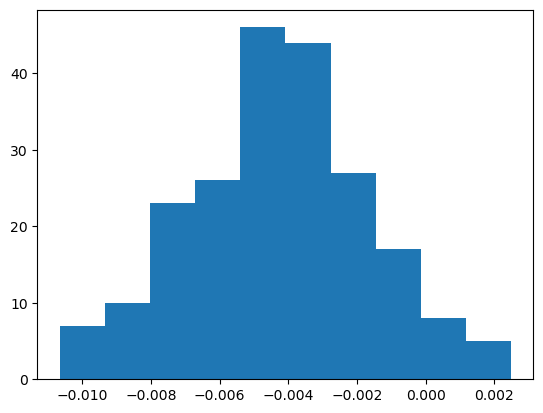

In [14]:
plt.hist(d1)

In [15]:
colors = [np.array(mpl.colors.to_rgb(mpl.colors.cnames[_]))
          for _ in ['darkgreen', 'lightgreen', 'red', 'pink']]
c1 = (colors[0] + colors[1]) * 0.5
c2 = (colors[2] + colors[3]) * 0.5

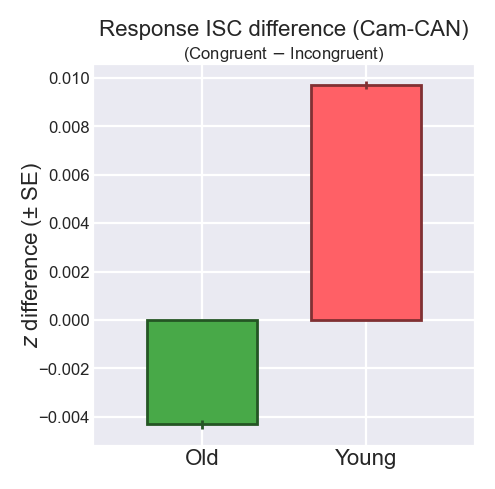

In [20]:
with sns.axes_style('darkgrid'):
    fig, ax = plt.subplots(1, 1, figsize=[_/3 for _ in [7, 7]], dpi=200)
    
    kwargs = dict(fmt='', lw=1)
    ax.bar(0, m1, color=c1, ec=c1*0.5, width=1)
    ax.bar(1.5, m2, color=c2, ec=c2*0.5, width=1)
    ax.errorbar(0, m1, yerr=se1, c=c1*0.5, **kwargs)
    ax.errorbar(1.5, m2, yerr=se2, c=c2*0.5, **kwargs)
    ax.tick_params(size=0, pad=1, labelsize=6)
    ax.set_xticks([0, 1.5], labels=['Old', 'Young'], size=8)
    ax.set_ylabel('$z$ difference (± SE)', size=8, labelpad=-2)
    # ax.set_yticks(np.arange(5)*0.01, labels=['0', '', '0.002', '', '0.004'])
    # ax.set_title('ISC difference (congruent - incongruent)', size=8, pad=3)
    ax.set_title('Response ISC difference (Cam-CAN)', size=8, pad=10, loc='center')
    ax.annotate('(Congruent $-$ Incongruent)', (0.5, 1.0), xycoords='axes fraction', ha='center', va='bottom', size=6)
    ax.set_xlim([-1, 2.5])
    fig.subplots_adjust(left=0.16, top=0.88, bottom=0.06, right=0.98)
    plt.savefig('figures/response_isc_diff_camcan.png', dpi=300)
    plt.show()

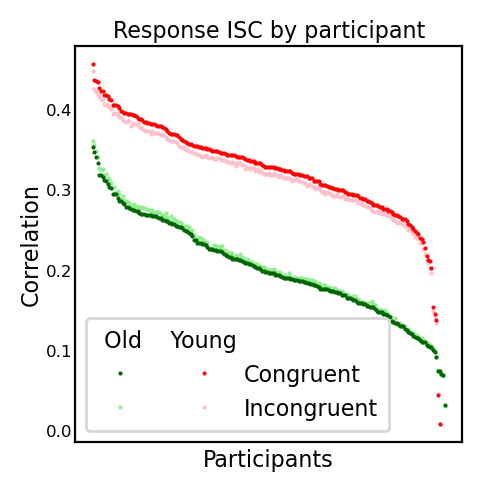

In [18]:
fig, ax = plt.subplots(1, 1, figsize=[_/3 for _ in [7, 7]], dpi=200)
handles = []
for ii, (a, b) in enumerate([[zz['old', 'old', 'procr'], zz['old', 'young', 'procr']], [zz['young', 'young', 'procr'], zz['young', 'old', 'procr']]]):
    # with sns.axes_style('darkgrid'):
        idx = np.argsort(a)[::-1]
        # idx = np.argsort((a + b))[::-1]
        a, b = np.tanh(a[idx]), np.tanh(b[idx])
        x = np.arange(len(a))
        kwargs = dict(markersize=1)
        handles += ax.plot(x, b, '.', color=colors[ii*2+1], **kwargs)
        handles += ax.plot(x, a, '.', color=colors[ii*2], **kwargs)
handles = [handles[_] for _ in [1, 0, 3, 2]]
ax.tick_params(size=0, pad=1, labelsize=6)
ax.set_ylabel('Correlation', size=8, labelpad=1)
ax.set_xticks([])
ax.set_xlabel('Participants', size=8, labelpad=2)
ax.set_title('Response ISC by participant', size=8, pad=3)
ax.legend(handles=handles, labels=['', '', 'Congruent', 'Incongruent'], ncols=2, columnspacing=1, fontsize=8,
         title=' Old    Young', title_fontsize=8, alignment='left', borderpad=0.5, fancybox=True)
fig.subplots_adjust(left=0.15, top=0.92, bottom=0.07, right=0.98)
plt.savefig('figures/response_isc_dist_camcan.png', dpi=300)
plt.show()

In [182]:
handles

[[<matplotlib.lines.Line2D at 0x33936af30>],

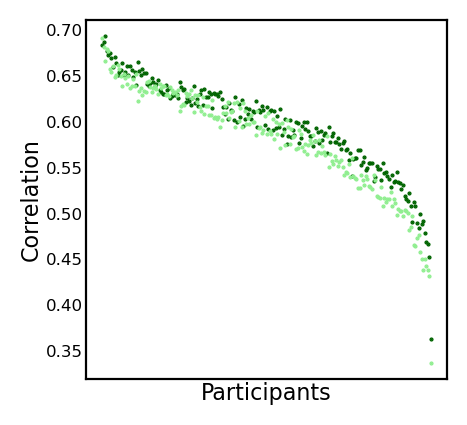

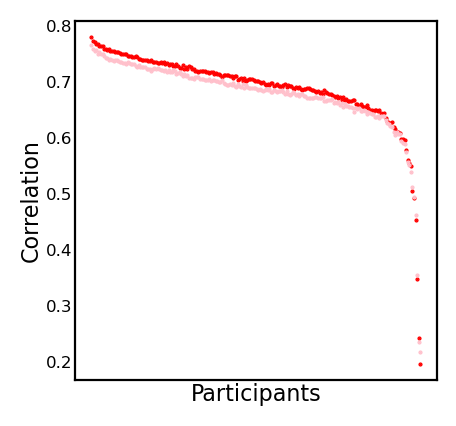

In [160]:
for ii, (a, b) in enumerate([[zz['old', 'old'], zz['old', 'young']], [zz['young', 'young'], zz['young', 'old']]]):
    # with sns.axes_style('darkgrid'):
        fig, ax = plt.subplots(1, 1, figsize=[_/3 for _ in [7, 7]], dpi=200)
        idx = np.argsort((a + b))[::-1]
        a, b = np.tanh(a[idx]), np.tanh(b[idx])
        x = np.arange(len(a))
        kwargs = dict(markersize=1)
        ax.plot(x, a, '.', color=colors[ii*2], **kwargs)
        ax.plot(x, b, '.', color=colors[ii*2+1], **kwargs)

        ax.tick_params(size=0, pad=1, labelsize=6)
        ax.set_ylabel('Correlation', size=8, labelpad=1)
        ax.set_xticks([])
        ax.set_xlabel('Participants', size=8, labelpad=1)
        plt.show()

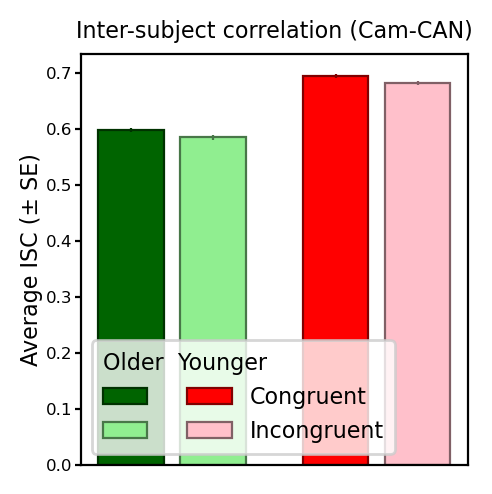

In [87]:
fig, ax = plt.subplots(1, 1, figsize=[_/3 for _ in [7, 7]], dpi=200)

bars = []
for ii, (x, z, c) in enumerate(config):
    c = colors[ii]
    ec = 0.5 * np.array(c)
    zm = z.mean()
    ze = z.std(ddof=1)/np.sqrt(len(z))
    m = np.tanh(zm)
    yerr = np.abs(np.tanh([zm-ze, zm+ze]) - m)
    b = ax.bar(x, m, color=c, ec=ec, lw=0.8)
    bars.append(b)
    ax.errorbar(x, m, yerr=yerr[:, None], color=ec, lw=0.8)
ax.set_xticks([])
ax.tick_params(size=2, pad=1, labelsize=6)
ax.set_ylabel('Average ISC (± SE)', size=8, labelpad=1)
ax.legend(handles=bars, labels=['', '', 'Congruent', 'Incongruent'], ncols=2, columnspacing=1, fontsize=8,
         title='Older  Younger', title_fontsize=8, alignment='left', borderpad=0.5, fancybox=True)
ax.set_title('Inter-subject correlation (Cam-CAN)', size=8)
fig.subplots_adjust(left=0.15, right=0.98, top=0.9, bottom=0.02)
plt.savefig('figures/isc_errorbar_camcan.png', dpi=300)
plt.show()

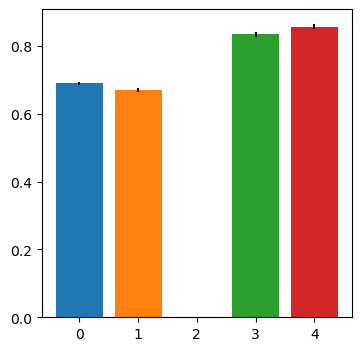

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
for ii, test_grp in enumerate(['old', 'young']):
    for jj, tpl_grp in enumerate(['old', 'young']):
        z = zz[test_grp, tpl_grp]
        x = ii * 3 + jj
        ax.bar(x, z.mean())
        ax.errorbar(x, z.mean(), yerr=z.std(ddof=1)/np.sqrt(len(z)), color='k')
plt.show()

In [13]:
ttest_rel(zz['old', 'old'], zz['old', 'young'])

TtestResult(statistic=np.float64(11.333590064196658), pvalue=np.float64(1.3821119150164137e-23), df=np.int64(212))

In [14]:
ttest_rel(zz['young', 'young'], zz['young', 'old'])

TtestResult(statistic=np.float64(30.091547363665416), pvalue=np.float64(6.627334444998706e-78), df=np.int64(209))

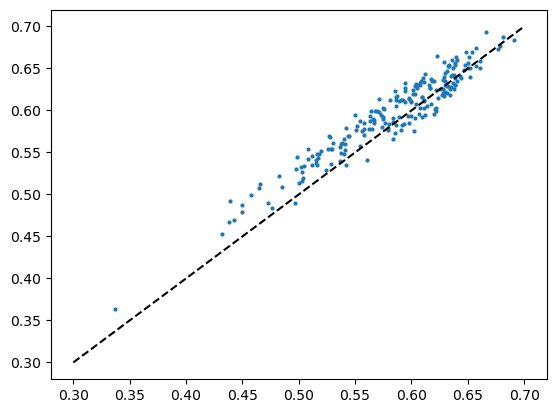

In [24]:
plt.scatter(np.tanh(zz['old', 'young']), np.tanh(zz['old', 'old']), s=4)
lim = [0.3, 0.7]
plt.plot(lim, lim, 'k--')
plt.show()

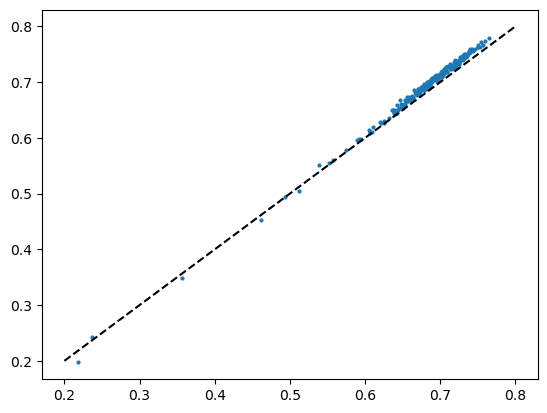

In [22]:
plt.scatter(np.tanh(zz['young', 'old']), np.tanh(zz['young', 'young']), s=4)
lim = [0.2, 0.8]
plt.plot(lim, lim, 'k--')
plt.show()